In [17]:
#!pip install xarray
#!pip install scipy
#!pip install cdsapi

#### Import Libraries

In [18]:
import xarray as xr
import numpy as np
import pandas as pd
import marineHeatWaves as mhw
import datetime as dt

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata
from matplotlib.gridspec import GridSpec

## Get Baseline

In [19]:
def spatial_subset(ds):
    out = ds.sel(lon = slice(350.0, 355.0),
                 lat = slice(36.0, 42.3))
    return out

In [20]:
baseline_df = pd.DataFrame()
for year in range(1991, 2022):

    var = xr.open_dataset(f"oisst_daily/sst.day.mean.{year}.nc", 
                        engine="netcdf4", decode_times=True)
    
    print(f'Opening {year}')
    
    var_sel = spatial_subset(var)
    
    var_sst = var_sel["sst"]

    baseline_df = pd.concat([baseline_df, var_sst.to_dataframe()])
    
del var

Opening 1991
Opening 1992
Opening 1993
Opening 1994
Opening 1995
Opening 1996
Opening 1997
Opening 1998
Opening 1999
Opening 2000
Opening 2001
Opening 2002
Opening 2003
Opening 2004
Opening 2005
Opening 2006
Opening 2007
Opening 2008
Opening 2009
Opening 2010
Opening 2011
Opening 2012
Opening 2013
Opening 2014
Opening 2015
Opening 2016
Opening 2017
Opening 2018
Opening 2019
Opening 2020
Opening 2021


## Years to be Analysed

In [21]:
y2022 = xr.open_dataset("oisst_daily/sst.day.mean.2022.nc", 
                        engine="netcdf4", decode_times=True)
y2023 = xr.open_dataset("oisst_daily/sst.day.mean.2023.nc", 
                        engine="netcdf4", decode_times=True)
y2024 = xr.open_dataset("oisst_daily/sst.day.mean.2024.nc", 
                        engine="netcdf4", decode_times=True)
y2025 = xr.open_dataset("oisst_daily/sst.day.mean.2025.nc", 
                        engine="netcdf4", decode_times=True)

print(y2023)

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 365, lat: 720, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2023-01-01 2023-01-02 ... 2023-12-31
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    sst      (time, lat, lon) float32 2GB ...
Attributes:
    Conventions:    CF-1.5
    title:          NOAA/NCEI 1/4 Degree Daily Optimum Interpolation Sea Surf...
    institution:    NOAA/National Centers for Environmental Information
    source:         NOAA/NCEI https://www.ncei.noaa.gov/data/sea-surface-temp...
    References:     https://www.psl.noaa.gov/data/gridded/data.noaa.oisst.v2....
    dataset_title:  NOAA Daily Optimum Interpolation Sea Surface Temperature
    version:        Version 2.1
    comment:        Reynolds, et al.(2007) Daily High-Resolution-Blended Anal...


#### Slice datasets' coordinates

In [22]:
y2022_sel = spatial_subset(y2022)
y2022_sst = y2022_sel["sst"]
y2022_time = y2022_sel["time"]

y2023_sel = spatial_subset(y2023)
y2023_sst = y2023_sel["sst"]
y2023_time = y2023_sel["time"]

y2024_sel = spatial_subset(y2024)
y2024_sst = y2024_sel["sst"]
y2024_time = y2024_sel["time"]

y2025_sel = spatial_subset(y2025)
y2025_sst = y2025_sel["sst"]
y2025_time = y2025_sel["time"]

In [23]:
baseline_df = baseline_df.reset_index()

y2022_df = y2022_sst.to_dataframe().reset_index()
y2023_df = y2023_sst.to_dataframe().reset_index()
y2024_df = y2024_sst.to_dataframe().reset_index()
y2025_df = y2025_sst.to_dataframe().reset_index()

In [24]:
def to_ordinal(time_array):
    ordinals = []

    for t in time_array:
        # Case 1: numpy.datetime64
        if isinstance(t, np.datetime64):
            ts = pd.Timestamp(t)
            ordinals.append(ts.to_pydatetime().date().toordinal())

        # Case 2: cftime objects
        else:
            ordinals.append(dt.date(t.year, t.month, t.day).toordinal())

    return np.array(ordinals)

### Detect MHWs

In [25]:
def detect_mhw_year(year_df, baseline_df, climatology_period=(1991, 2021)):
    
    results = []

    for (lat, lon), group_year in year_df.groupby(["lat", "lon"]):

        # --- year data ---
        y_sst = group_year["sst"].values
        y_time = group_year["time"].values
        y_time_ord = to_ordinal(y_time)

        # --- baseline for same grid cell ---
        base_group = baseline_df[
            (baseline_df["lat"] == lat) &
            (baseline_df["lon"] == lon)
        ]

        if base_group.empty:
            continue

        base_sst = base_group["sst"].values
        base_time = base_group["time"].values
        base_time_ord = to_ordinal(base_time)

        base_years = pd.to_datetime(base_time).year

        if (base_years.min() > climatology_period[0] or
            base_years.max() < climatology_period[1]):
            continue

        # --- MHW detection ---
        mhw_ev, clim = mhw.detect(
            y_time_ord,
            y_sst,
            climatologyPeriod= list(climatology_period),
            alternateClimatology= [base_time_ord, base_sst]
        )

        results.append({
            "year": pd.to_datetime(y_time[0]).year,
            "lat": lat,
            "lon": lon,
            "n_events": mhw_ev["n_events"],
            "total_duration": (
                np.sum(mhw_ev["duration"])
            ),
            "max_intensity": (
                np.max(mhw_ev["intensity_max"])
                if mhw_ev["n_events"] > 0 else np.nan
            )
        })

    return pd.DataFrame(results)


In [26]:
df_2022 = detect_mhw_year(y2022_df, baseline_df)
df_2023 = detect_mhw_year(y2023_df, baseline_df)
df_2024 = detect_mhw_year(y2024_df, baseline_df)
df_2025 = detect_mhw_year(y2025_df, baseline_df)

yearly_dfs = {
    2022: df_2022,
    2023: df_2023,
    2024: df_2024,
    2025: df_2025
}

/opt/anaconda3/envs/MHW/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1406: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/Users/miguelsilveira/Documents/GitHub/marineheatwaves/marineHeatWaves.py:281: RuntimeWarning: Mean of empty slice
  seas_climYear[d-1] = np.nanmean(tempClim[tt.astype(int)])
/Users/miguelsilveira/Documents/GitHub/marineheatwaves/marineHeatWaves.py:411: RuntimeWarning: invalid value encountered in scalar divide
  mhw['rate_decline'].append((mhw_relSeas[tt_peak] - mhw_relSeas[-1]) / (tt_end-tt_start-tt_peak))
/Users/miguelsilveira/Documents/GitHub/marineheatwaves/marineHeatWaves.py:411: RuntimeWarning: invalid value encountered in scalar divide
  mhw['rate_decline'].append((mhw_relSeas[tt_peak] - mhw_relSeas[-1]) / (tt_end-tt_start-tt_peak))
/opt/anaconda3/envs/MHW/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1406: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/Users/miguelsilvei

## Graphs

#### By number of events

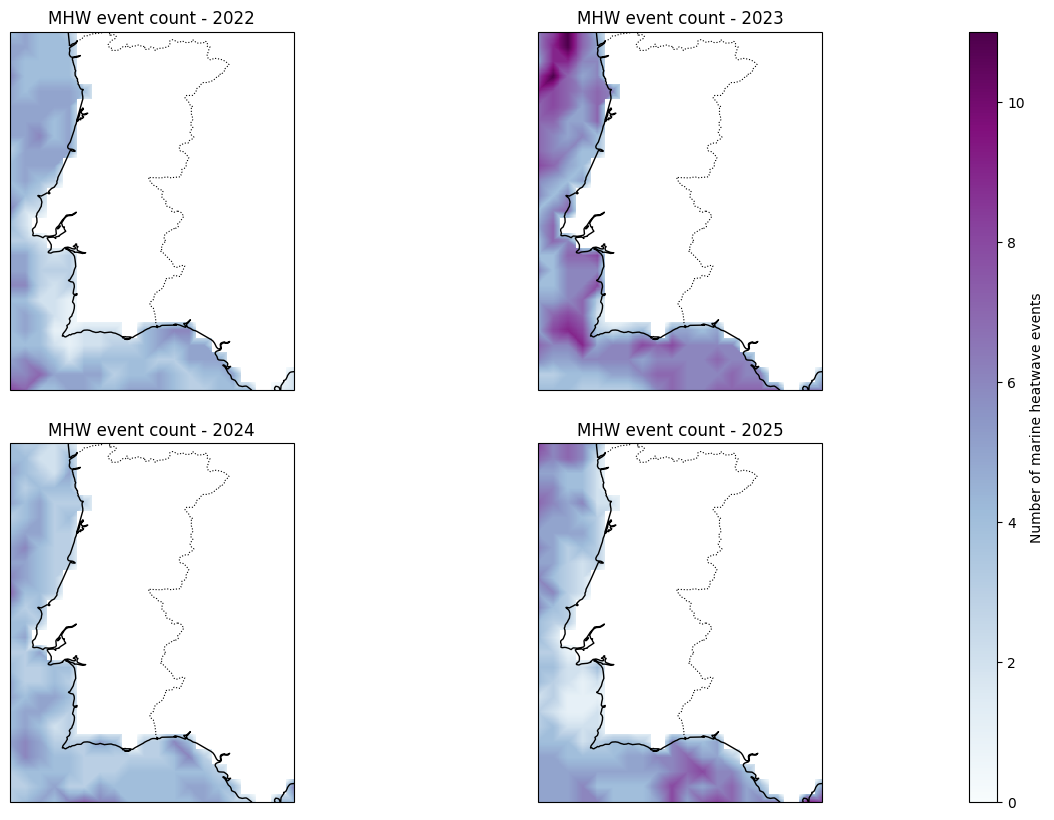

In [27]:
# Open ONE SST file (any year is fine)
ds_mask = y2022_sel

# TRUE ocean mask (True = ocean, False = land)
ocean_mask = ~np.isnan(ds_mask["sst"].isel(time=0))

# -------------------------------------------------
# Figure layout
# -------------------------------------------------
fig = plt.figure(figsize=(14, 10))
gs = GridSpec(2, 3, width_ratios=[1, 1, 0.06], wspace=0.15, hspace=0.15)

axes = [
    fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree()),
]

cax = fig.add_subplot(gs[:, 2])  # colorbar axis

# -------------------------------------------------
# Shared color scale
# -------------------------------------------------
vmin = 0
vmax = max(df["n_events"].max() for df in yearly_dfs.values())

# -------------------------------------------------
# Plot each year
# -------------------------------------------------
for ax, (year, df) in zip(axes, yearly_dfs.items()):

    lats = df["lat"].values
    lons = df["lon"].values
    counts = df["n_events"].values

    # Interpolation grid
    lon_grid = np.linspace(lons.min(), lons.max(), 300)
    lat_grid = np.linspace(lats.min(), lats.max(), 300)
    lon_grid, lat_grid = np.meshgrid(lon_grid, lat_grid)

    # -----------------------------
    # Interpolate MHW counts
    # -----------------------------
    grid_counts = griddata(
        (lons, lats),
        counts,
        (lon_grid, lat_grid),
        method="linear"
    )

    # -----------------------------
    # Interpolate TRUE land–sea mask
    # -----------------------------
    # -------------------------------------------------
    # Build lon/lat grid from the SST mask dataset
    # -------------------------------------------------
    lon2d, lat2d = np.meshgrid(
        ds_mask["lon"].values,
        ds_mask["lat"].values
    )

    # -------------------------------------------------
    # Interpolate TRUE land–sea mask
    # -------------------------------------------------
    mask_interp = griddata(
        (lon2d.ravel(), lat2d.ravel()),
        ocean_mask.values.ravel().astype(float),
        (lon_grid, lat_grid),
        method="nearest"
    )

    # Apply mask
    grid_counts = np.ma.masked_where(mask_interp < 0.5, grid_counts)

    # -----------------------------
    # Map styling
    # -----------------------------
    ax.set_extent(
        [lons.min(), lons.max(), lats.min(), lats.max()],
        crs=ccrs.PlateCarree()
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.8)

    mesh = ax.pcolormesh(
        lon_grid,
        lat_grid,
        grid_counts,
        cmap="BuPu",
        shading="auto",
        vmin=vmin,
        vmax=vmax,
        transform=ccrs.PlateCarree()
    )

    ax.set_title(f"MHW event count - {year}")

# -------------------------------------------------
# Colorbar (guaranteed no overlap)
# -------------------------------------------------
cbar = fig.colorbar(mesh, cax=cax)
cbar.set_label("Number of marine heatwave events")

plt.show()


#### By total duration

In [28]:
df_2022

,year,lat,lon,n_events,total_duration,max_intensity
0,2022,36.125,350.125,8,126.0,1.766405
1,2022,36.125,350.375,7,119.0,1.767546
2,2022,36.125,350.625,4,90.0,1.846186
3,2022,36.125,350.875,4,89.0,2.046540
4,2022,36.125,351.125,5,99.0,2.151048
...,...,...,...,...,...,...
495,2022,42.125,353.875,0,0.0,NaN
496,2022,42.125,354.125,0,0.0,NaN
497,2022,42.125,354.375,0,0.0,NaN
498,2022,42.125,354.625,0,0.0,NaN


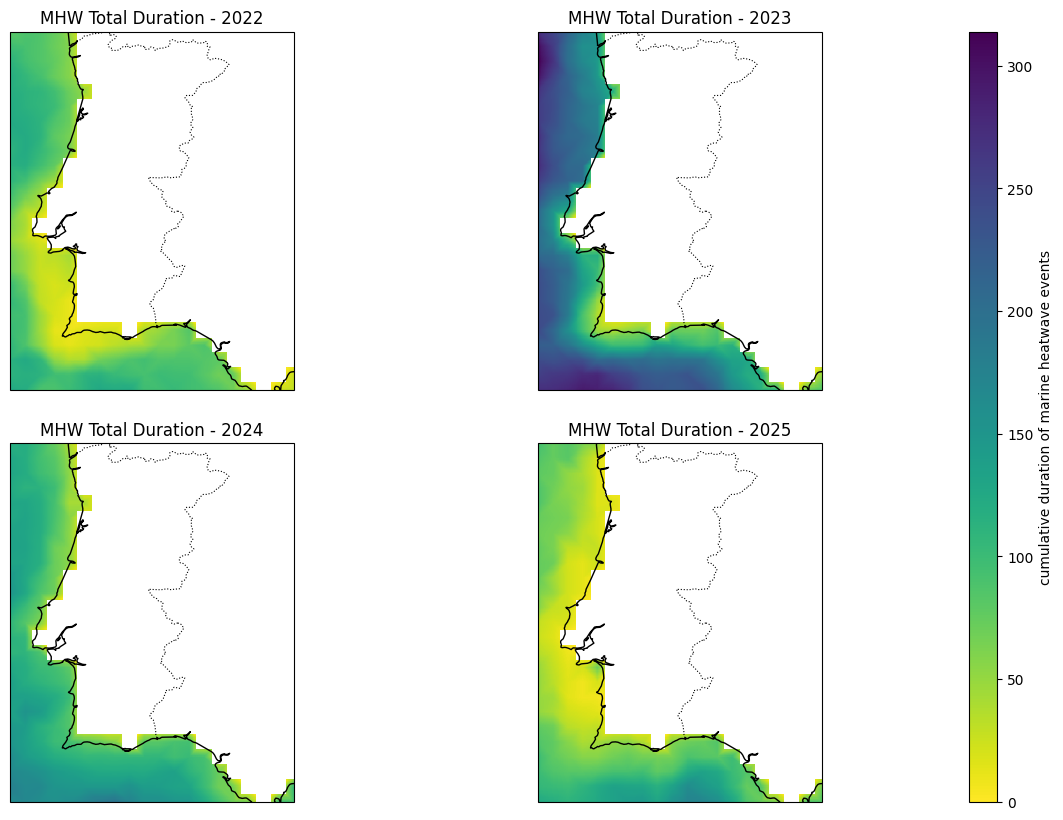

In [35]:
# -------------------------------------------------
# Figure layout (explicit, no overlap)
# -------------------------------------------------
fig = plt.figure(figsize=(14, 10))
gs = GridSpec(2, 3, width_ratios=[1, 1, 0.06], wspace=0.15, hspace=0.15)

axes = [
    fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree()),
]

cax = fig.add_subplot(gs[:, 2])  # colorbar axis

# -------------------------------------------------
# Shared color scale
# -------------------------------------------------
vmin = 0
vmax = max(df["total_duration"].max() for df in yearly_dfs.values())


# -------------------------------------------------
# Plot each year
# -------------------------------------------------
for ax, (year, df) in zip(axes, yearly_dfs.items()):

    lats = df["lat"].values
    lons = df["lon"].values
    counts = df["total_duration"].values

    # Interpolation grid
    lon_grid = np.linspace(lons.min(), lons.max(), 300)
    lat_grid = np.linspace(lats.min(), lats.max(), 300)
    lon_grid, lat_grid = np.meshgrid(lon_grid, lat_grid)

    # -----------------------------
    # Interpolate MHW counts
    # -----------------------------
    grid_counts = griddata(
        (lons, lats),
        counts,
        (lon_grid, lat_grid),
        method="linear"
    )

    # -----------------------------
    # Interpolate TRUE land–sea mask
    # -----------------------------
    # -------------------------------------------------
    # Build lon/lat grid from the SST mask dataset
    # -------------------------------------------------
    lon2d, lat2d = np.meshgrid(
        ds_mask["lon"].values,
        ds_mask["lat"].values
    )

    # -------------------------------------------------
    # Interpolate TRUE land–sea mask
    # -------------------------------------------------
    mask_interp = griddata(
        (lon2d.ravel(), lat2d.ravel()),
        ocean_mask.values.ravel().astype(float),
        (lon_grid, lat_grid),
        method="nearest"
    )

    # Apply mask
    grid_counts = np.ma.masked_where(mask_interp < 0.5, grid_counts)


    # Apply mask (THIS removes the triangle)
    grid_counts = np.ma.masked_where(mask_interp < 0.5, grid_counts)

    # -----------------------------
    # Map styling
    # -----------------------------
    ax.set_extent(
        [lons.min(), lons.max(), lats.min(), lats.max()],
        crs=ccrs.PlateCarree()
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.8)

    mesh = ax.pcolormesh(
        lon_grid,
        lat_grid,
        grid_counts,
        cmap="viridis_r",
        shading="auto",
        vmin=vmin,
        vmax=vmax,
        transform=ccrs.PlateCarree()
    )

    ax.set_title(f"MHW Total Duration - {year}")

# -------------------------------------------------
# Colorbar (guaranteed no overlap)
# -------------------------------------------------
cbar = fig.colorbar(mesh, cax=cax)
cbar.set_label("cumulative duration of marine heatwave events")


plt.show()

In [30]:
for year, df in yearly_dfs.items():
    print(year, df["total_duration"].describe())


2022 count    500.000000
mean      25.196000
std       40.398188
min        0.000000
25%        0.000000
50%        0.000000
75%       47.250000
max      126.000000
Name: total_duration, dtype: float64
2023 count    500.000000
mean      63.032000
std       96.481648
min        0.000000
25%        0.000000
50%        0.000000
75%      142.250000
max      314.000000
Name: total_duration, dtype: float64
2024 count    500.000000
mean      38.234000
std       57.183557
min        0.000000
25%        0.000000
50%        0.000000
75%       93.000000
max      194.000000
Name: total_duration, dtype: float64
2025 count    500.000000
mean      22.738000
std       39.425958
min        0.000000
25%        0.000000
50%        0.000000
75%       33.250000
max      173.000000
Name: total_duration, dtype: float64


In [31]:
'''mhw_ev,clim = mhw.detect(y2023_time_ord, y2023_sst, 
                         climatologyPeriod=[1991, 2021],
                         alternateClimatology= [baseline_time_ord, baseline_sst])'''

'mhw_ev,clim = mhw.detect(y2023_time_ord, y2023_sst, \n                         climatologyPeriod=[1991, 2021],\n                         alternateClimatology= [baseline_time_ord, baseline_sst])'

In [32]:
'''mhw_ev['n_events']'''

"mhw_ev['n_events']"